##### **1. Register and Index Your Dataset**

In [1]:
from deepface import DeepFace

26-10-03 01:39:20 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



I0000 00:00:1790971761.238596  125021 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790971761.240042  125021 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790971763.442094  125021 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790971763.444660  125021 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Define your custom database path: raw data
# custom_db_path = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
custom_db_path = "../datasets/raw_data/"

In [ ]:
# Run a dummy search or explicitly call representation generation to create the database index
# This step extracts embeddings and saves a '.pkl' file inside your folder
df_list = DeepFace.find(
    img_path="../datasets/images/Tejrit.jpg", 
    db_path=custom_db_path,
    model_name="Facenet512",      # Highly accurate model choice
    detector_backend="mtcnn",     # High accuracy face finder
    enforce_detection=False       # Prevents crashing if an image lacks a clear face
)

print("Custom dataset indexed successfully!")

26-10-03 01:32:25 - Found 513 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   4%|▎         | 18/513 [06:39<3:56:18, 28.64s/it]

In [2]:
import os
import pandas as pd
from deepface import DeepFace

def recognize_face(img_path, db_path):
    # 1. Run the search against your custom database folder
    # We use 'refresh_database=True' to ensure any new images you added are indexed
    results = DeepFace.find(
        img_path=img_path, 
        db_path=db_path,
        model_name="Facenet512",      # Robust embedding model
        detector_backend="mtcnn",     # High-accuracy face detector
        refresh_database=True,        # Updates the .pkl file automatically if files changed
        enforce_detection=False       # Prevents script from crashing if no face is in source
    )
    
    # DeepFace.find returns a list of dataframes (one per face detected in the source image)
    if not results or results[0].empty:
        print("❌ No matching face found in the database.")
        return None
        
    df = results[0]
    
    # 2. Extract the best match (the first row has the lowest distance / highest confidence)
    best_match_path = df.iloc[0]['identity']
    confidence = df.iloc[0]['confidence']
    distance = df.iloc[0]['distance']
    
    # 3. Parse the directory name to get the person's identity
    # E.g., /path/to/my_custom_db/Tejrit/pic1.jpg -> "Tejrit"
    person_name = os.path.basename(os.path.dirname(best_match_path))
    
    print(f"✅ Match Found: {person_name}")
    print(f"📊 Confidence: {confidence:.2f}% | Distance: {distance:.4f}")
    
    return person_name, df




# --- Execution ---
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "../Datasets/Tejrit.jpg"

name, full_dataframe = recognize_face(QUERY_IMAGE, DATABASE_DIR)


26-10-03 01:40:17 - Searching ../Datasets/Tejrit.jpg in 40 length datastore
26-10-03 01:40:18 - find function duration 12.61328125 seconds
✅ Match Found: Tejrit Tyagi
📊 Confidence: 100.00% | Distance: 0.0540


🔍 Searching database...
26-10-03 01:40:43 - Searching ../Datasets/Tejrit.jpg in 40 length datastore
26-10-03 01:40:43 - find function duration 10.60323452949524 seconds


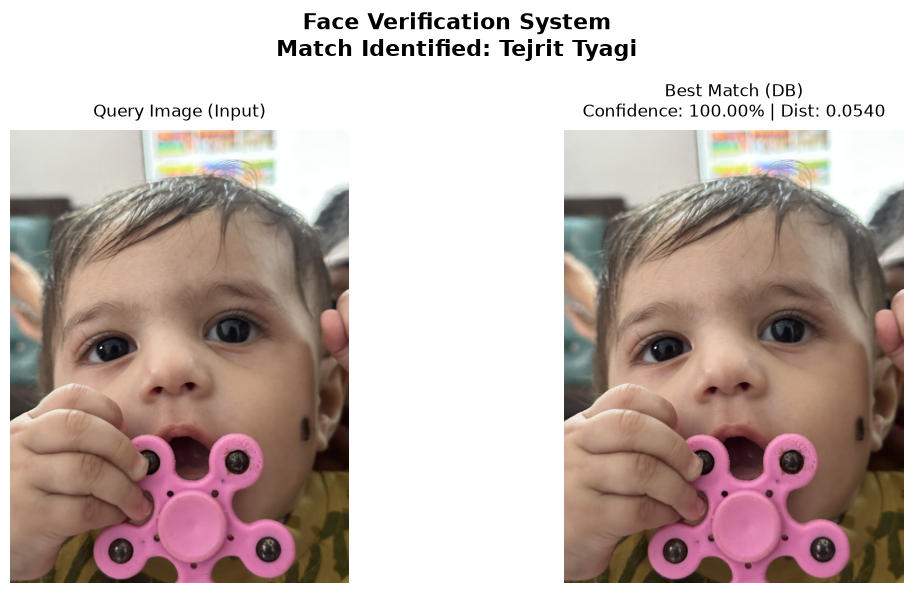

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# 1. Configuration
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "../Datasets/Tejrit.jpg"

print("🔍 Searching database...")
# 2. Run DeepFace Match
results = DeepFace.find(
    img_path=QUERY_IMAGE, 
    db_path=DATABASE_DIR,
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)

# DeepFace returns a list containing a DataFrame
df = results[0] if isinstance(results, list) else results

if not df.empty:
    # 3. Extract top match details
    best_match_path = df.iloc[0]['identity']
    confidence = df.iloc[0]['confidence']
    distance = df.iloc[0]['distance']
    person_name = os.path.basename(os.path.dirname(best_match_path))
    
    # 4. Load images with OpenCV
    img_query = cv2.imread(QUERY_IMAGE)
    img_match = cv2.imread(best_match_path)
    
    # Convert from BGR (OpenCV default) to RGB (Matplotlib default)
    img_query = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)
    img_match = cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB)
    
    # 5. Plot using Matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Face Verification System\nMatch Identified: {person_name}", fontsize=16, fontweight='bold', y=0.98)
    
    # Left subplot: Query Image
    axes[0].imshow(img_query)
    axes[0].set_title("Query Image (Input)", fontsize=12, pad=10)
    axes[0].axis('off')
    
    # Right subplot: Database Match
    axes[1].imshow(img_match)
    axes[1].set_title(f"Best Match (DB)\nConfidence: {confidence:.2f}% | Dist: {distance:.4f}", fontsize=12, pad=10)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ No matching face found in the database.")


In [ ]:
import os
import cv2
import math
import matplotlib.pyplot as plt
from deepface import DeepFace

# 1. Configuration
# DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
DATABASE_DIR = "../datasets/raw_data/"
QUERY_IMAGE = "../datasets/images/Tejrit.jpg"
DISTANCE_THRESHOLD = 0.60  # Only show matches with a distance strictly lower than this

print("🔍 Searching database for matches...")
# 2. Run DeepFace Match
results = DeepFace.find(
    img_path=QUERY_IMAGE, 
    db_path=DATABASE_DIR,
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)

# Extract dataframe from list format if needed
df = results[0] if isinstance(results, list) else results

# 3. Filter results based on the custom threshold
matched_df = df[df['distance'] < DISTANCE_THRESHOLD]

if not matched_df.empty:
    num_matches = len(matched_df)
    print(f"✅ Found {num_matches} matching images below threshold {DISTANCE_THRESHOLD}")
    
    # Calculate grid dimensions (1 input image + N matched images)
    total_plots = 1 + num_matches
    cols = 4  # Maximum 4 images per row
    rows = math.ceil(total_plots / cols)
    
    # 4. Set up the Matplotlib Figure layout
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() # Flatten to index linearly easily
    
    # Load and convert Query Image (BGR to RGB)
    img_query = cv2.imread(QUERY_IMAGE)
    img_query = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)
    
    # Plot Input Image in slot 0
    axes[0].imshow(img_query)
    axes[0].set_title("Input (Query Image)", fontsize=11, fontweight='bold', color='blue')
    axes[0].axis('off')
    
    # 5. Loop over the filtered matches and fill the remaining grid slots
    for i, idx in enumerate(matched_df.index):
        row = matched_df.loc[idx]
        best_match_path = row['identity']
        confidence = row['confidence']
        distance = row['distance']
        person_name = os.path.basename(os.path.dirname(best_match_path))
        filename = os.path.basename(best_match_path)
        
        # Load and convert Match Image
        img_match = cv2.imread(best_match_path)
        img_match = cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB)
        
        # Render current image in the grid
        plot_idx = i + 1
        axes[plot_idx].imshow(img_match)
        axes[plot_idx].set_title(
            f"Match #{plot_idx}: {person_name}\nConf: {confidence:.1f}%\nDist: {distance:.3f}\nFile: {filename[:15]}...", 
            fontsize=10
        )
        axes[plot_idx].axis('off')
        
    # Turn off any remaining unused axes in the grid
    for j in range(total_plots, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ No matching face found under the distance threshold of {DISTANCE_THRESHOLD}.")


🔍 Searching database for matches...
26-10-03 01:42:30 - Found 513 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   3%|▎         | 14/513 [04:58<3:10:42, 22.93s/it]

#### **How to Update Your Dataset Later**

- **Adding New Photos:** If you add new people or new images to your folder, DeepFace will not automatically see them because it reads from the cached .pkl file.
- **Updating the Database:** Force DeepFace to rebuild its index matrix by adding the refresh_database=True argument:

use **refresh_database=True** parameter

### **Multi-Face Recognition & Visualization Script**

In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from deepface import DeepFace

# 1. Configuration
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "../datasets/images/group_photo.jpg"  # Replace with your multi-face image path
DISTANCE_THRESHOLD = 0.60

🔍 Extracting and matching all faces in the query image...
26-10-03 00:53:27 - Searching ../datasets/images/group_photo.jpg in 40 length datastore
26-10-03 00:53:28 - find function duration 13.247190713882446 seconds


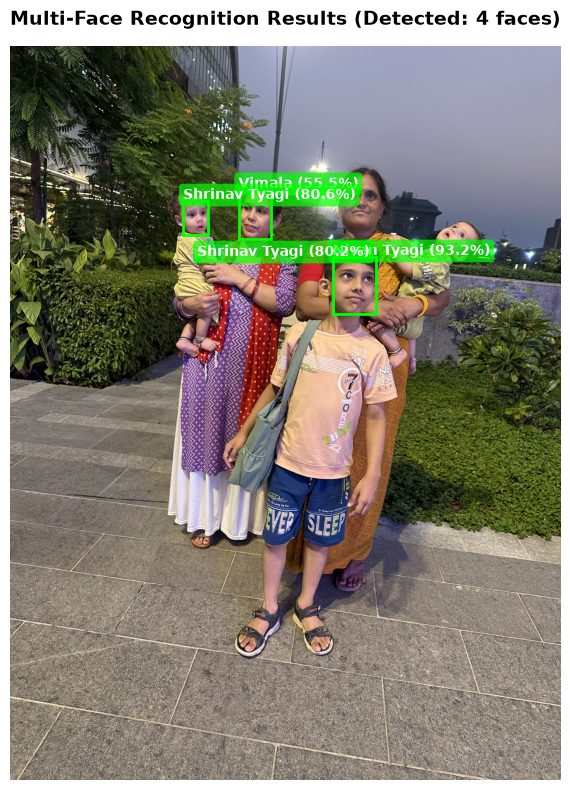

✅ Processing complete. Visualized 4 faces.

📋 FACIAL RECOGNITION MATCH REPORT | Query: group_photo.jpg

👤 Face #1:
  └── ❌ No matches found in the entire datastore.

👤 Face #2:
  ├── 🏆 Top Match: Name: Vimala          | Confidence: 55.54% | Distance: 0.2741 | DB Ref: IMG_5253.jpg
  ├── 👥 Alt Match: Name: Vimala          | Confidence: 53.26% | Distance: 0.2838 | DB Ref: IMG_5252.jpg

👤 Face #3:
  ├── 🏆 Top Match: Name: Shrinav Tyagi   | Confidence: 80.57% | Distance: 0.1699 | DB Ref: IMG_5273.jpg
  ├── 👥 Alt Match: Name: Shrinav Tyagi   | Confidence: 63.19% | Distance: 0.2420 | DB Ref: IMG_5274.jpg
  ├── 👥 Alt Match: Name: Shrinav Tyagi   | Confidence: 59.04% | Distance: 0.2593 | DB Ref: IMG_5270.jpg
  ├── 👥 Alt Match: Name: Shrinav Tyagi   | Confidence: 52.55% | Distance: 0.2868 | DB Ref: IMG_5275.jpg

👤 Face #4:
  ├── 🏆 Top Match: Name: Nivan Tyagi     | Confidence: 93.24% | Distance: 0.1165 | DB Ref: IMG_5255.jpg
  ├── 👥 Alt Match: Name: Nivan Tyagi     | Confidence: 92.17% | Distanc

In [7]:
print("🔍 Extracting and matching all faces in the query image...")

try:
    # 2. Run DeepFace.find
    # When an image contains multiple faces, DeepFace returns a LIST of DataFrames (one per face)
    results = DeepFace.find(
        img_path=QUERY_IMAGE, 
        db_path=DATABASE_DIR,
        model_name="Facenet512",
        detector_backend="mtcnn",
        enforce_detection=True
    )
except Exception as e:
    print(f"❌ Error during detection: {e}")
    results = []

# Ensure results is treated as a list of dataframes
if not isinstance(results, list):
    results = [results]

# 3. Load the background query image for plotting
img = cv2.imread(QUERY_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Setup Matplotlib plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_rgb)

faces_identified = 0

# 4. Loop over every unique face found in the query image
for i, df in enumerate(results):
    if df.empty:
        continue
        
    # Extract the crop coordinates of the current query face
    # These are identical across all rows for this specific face sub-query
    x = df.iloc[0]['source_x']
    y = df.iloc[0]['source_y']
    w = df.iloc[0]['source_w']
    h = df.iloc[0]['source_h']
    
    # Filter matches based on your threshold
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD]
    
    if not valid_matches.empty:
        # Grab the absolute closest structural match
        best_match = valid_matches.iloc[0]
        best_match_path = best_match['identity']
        confidence = best_match['confidence']
        
        # Parse folder name to isolate the individual's identity name
        person_name = os.path.basename(os.path.dirname(best_match_path))
        label = f"{person_name} ({confidence:.1f}%)"
        box_color = 'lime'  # Green for known/matched faces
    else:
        label = "Unknown"
        box_color = 'red'  # Red for unrecognized faces
        
    # 5. Draw the bounding box patch
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)
    
    # Draw text banner above the box
    ax.text(
        x, y - 10, label, 
        color='white', fontweight='bold', fontsize=10,
        bbox=dict(facecolor=box_color, alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
    )
    faces_identified += 1

ax.axis('off')
plt.title(f"Multi-Face Recognition Results (Detected: {faces_identified} faces)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"✅ Processing complete. Visualized {faces_identified} faces.")

# 3. Process results into a structured text report
print("\n" + "="*70)
print(f"📋 FACIAL RECOGNITION MATCH REPORT | Query: {os.path.basename(QUERY_IMAGE)}")
print("="*70)

total_faces_found = len(results)
unknown_count = 0

for face_idx, df in enumerate(results):
    print(f"\n👤 Face #{face_idx + 1}:")
    
    if df.empty:
        print("  └── ❌ No matches found in the entire datastore.")
        unknown_count += 1
        continue
        
    # Filter the dataframe to only keep items below our strict threshold distance
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD].copy()
    
    if valid_matches.empty:
        print("  └── 🛑 Bounded Face Detected, but all candidates fell below the threshold (Marked: Unknown).")
        unknown_count += 1
        continue
        
    # Extract identity name from the absolute paths
    valid_matches['Name'] = valid_matches['identity'].apply(lambda x: os.path.basename(os.path.dirname(x)))
    valid_matches['File'] = valid_matches['identity'].apply(lambda x: os.path.basename(x))
    
    # Sort with the highest confidence / lowest distance at the top
    valid_matches = valid_matches.sort_values(by='distance', ascending=True)
    
    # Print out each matching profile over the threshold
    for match_idx, row in enumerate(valid_matches.itertuples()):
        prefix = "  ├── 🏆 Top Match:" if match_idx == 0 else "  ├── 👥 Alt Match:"
        print(f"{prefix} Name: {row.Name:<15} | Confidence: {row.confidence:.2f}% | Distance: {row.distance:.4f} | DB Ref: {row.File}")

print("\n" + "="*70)
print(f"📊 SUMMARY: Processed {total_faces_found} total faces. Identified: {total_faces_found - unknown_count} | Unknowns: {unknown_count}")
print("="*70)

In [8]:
# 2. Print Report in Custom Format
print("\n" + "="*60)
print(f"FACIAL RECOGNITION MATCH REPORT | Query: {os.path.basename(QUERY_IMAGE)}")
print("="*60)

for face_idx, df in enumerate(results):
    print(f"\nFace #{face_idx + 1}")
    
    if df.empty:
        print("  Confidence & Distance: No Match Found")
        print("  Filename: N/A")
        continue
        
    # Filter the matches based on your threshold
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD].copy()
    
    if valid_matches.empty:
        print("  Confidence & Distance: Unknown (Below Threshold)")
        print("  Filename: N/A")
        continue
        
    # Sort with the best matches at the top
    valid_matches = valid_matches.sort_values(by='distance', ascending=True)
    
    # Grab the top match details
    best_match = valid_matches.iloc[0]
    person_name = os.path.basename(os.path.dirname(best_match['identity']))
    
    print(f"  Name: {person_name}")
    print(f"  Confidence: {best_match['confidence']:.2f}% | Distance: {best_match['distance']:.4f}")
    
    # Print all matching filenames underneath
    print("  Matching Files:")
    for idx, row in valid_matches.iterrows():
        filename = os.path.basename(row['identity'])
        print(f"    └── {filename} (Dist: {row['distance']:.4f})")

print("\n" + "="*60)


FACIAL RECOGNITION MATCH REPORT | Query: group_photo.jpg

Face #1
  Confidence & Distance: No Match Found
  Filename: N/A

Face #2
  Name: Vimala
  Confidence: 55.54% | Distance: 0.2741
  Matching Files:
    └── IMG_5253.jpg (Dist: 0.2741)
    └── IMG_5252.jpg (Dist: 0.2838)

Face #3
  Name: Shrinav Tyagi
  Confidence: 80.57% | Distance: 0.1699
  Matching Files:
    └── IMG_5273.jpg (Dist: 0.1699)
    └── IMG_5274.jpg (Dist: 0.2420)
    └── IMG_5270.jpg (Dist: 0.2593)
    └── IMG_5275.jpg (Dist: 0.2868)

Face #4
  Name: Nivan Tyagi
  Confidence: 93.24% | Distance: 0.1165
  Matching Files:
    └── IMG_5255.jpg (Dist: 0.1165)
    └── IMG_5257.jpg (Dist: 0.1211)
    └── IMG_5254.jpg (Dist: 0.1283)

Face #5
  Name: Shrinav Tyagi
  Confidence: 80.23% | Distance: 0.1713
  Matching Files:
    └── IMG_5275.jpg (Dist: 0.1713)
    └── IMG_5271.jpg (Dist: 0.1972)
    └── IMG_5253.jpg (Dist: 0.2243)
    └── IMG_5265.jpg (Dist: 0.2365)
    └── IMG_5264.jpg (Dist: 0.2622)

Face #6
  Confidence & Di

#### **Multi-Face Dashboard Visualization Script**

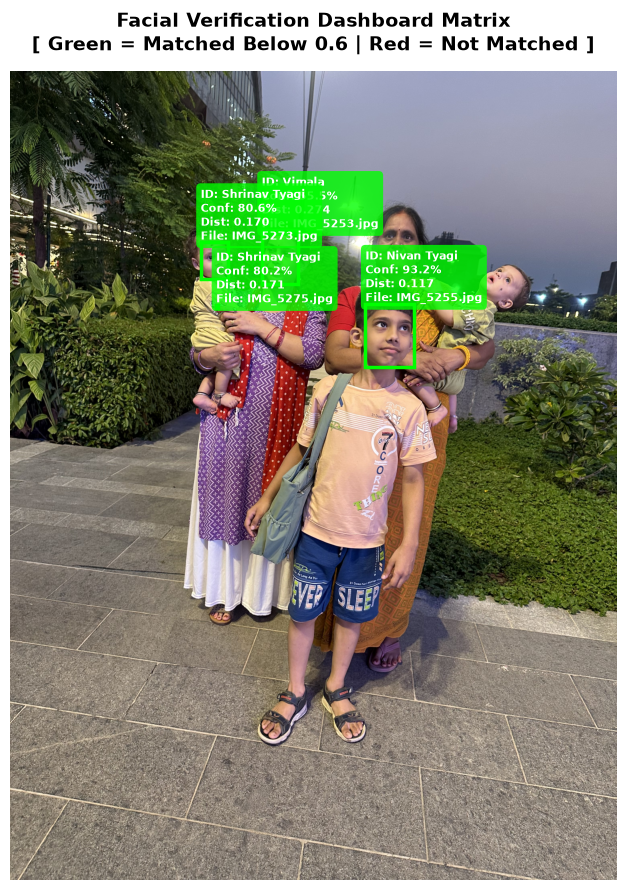

In [9]:
# Load Background Image
img = cv2.imread(QUERY_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img_rgb)

# 4. Loop Over Each Detected Face Frame
for face_idx, df in enumerate(results):
    if df.empty:
        continue
        
    # FIX: Use .loc[0, 'column_name'] to avoid the TypeError
    x = df.loc[0, 'source_x']
    y = df.loc[0, 'source_y']
    w = df.loc[0, 'source_w']
    h = df.loc[0, 'source_h']
    
    # Filter matches based on the threshold
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD]
    
    if not valid_matches.empty:
        # Sort to grab the best structural match record
        sorted_matches = valid_matches.sort_values(by='distance', ascending=True)
        
        # FIX: Use .iloc[0] to grab the first row object safely
        best_match = sorted_matches.iloc[0]
        best_match_path = best_match['identity']
        confidence = best_match['confidence']
        distance = best_match['distance']
        
        person_name = os.path.basename(os.path.dirname(best_match_path))
        filename = os.path.basename(best_match_path)
        
        label_text = f"ID: {person_name}\nConf: {confidence:.1f}%\nDist: {distance:.3f}\nFile: {filename}"
        box_color = '#00FF00'  # Bright Neon Green for matched
    else:
        label_text = f"Face #{face_idx + 1}\nUnknown\nNo Match Found"
        box_color = '#FF0000'  # Bright Red for Unmatched
        
    # Render Bounding Box Patch
    rect = patches.Rectangle((x, y), w, h, linewidth=2.5, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)
    
    # Overlay Multi-Line Metadata Details Box
    ax.text(
        x, y - 12, label_text, 
        color='white', fontweight='bold', fontsize=8,
        bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4')
    )

ax.axis('off')
plt.title(f"Facial Verification Dashboard Matrix\n[ Green = Matched Below {DISTANCE_THRESHOLD} | Red = Not Matched ]", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [48]:
import DeepFace_util

In [41]:
DeepFace_util.multi_face_dashboard(QUERY_IMAGE=QUERY_IMAGE, results=results)

TypeError: multi_face_dashboard() got an unexpected keyword argument 'results'

#### **Real-Time Webcam**

In [54]:
print("🔍 Extracting and matching all faces in the query image...")

try:
    # 2. Run DeepFace.find
    # When an image contains multiple faces, DeepFace returns a LIST of DataFrames (one per face)
    results = DeepFace.find(
        img_path=QUERY_IMAGE, 
        db_path=DATABASE_DIR,
        model_name="Facenet512",
        detector_backend="yolov8n",
        enforce_detection=True
    )
except Exception as e:
    print(f"❌ Error during detection: {e}")
    results = []

# Ensure results is treated as a list of dataframes
if not isinstance(results, list):
    results = [results]

# 3. Load the background query image for plotting
img = cv2.imread(QUERY_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Setup Matplotlib plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_rgb)

faces_identified = 0

# 4. Loop over every unique face found in the query image
for i, df in enumerate(results):
    if df.empty:
        continue
        
    # Extract the crop coordinates of the current query face
    # These are identical across all rows for this specific face sub-query
    x = df.iloc[0]['source_x']
    y = df.iloc[0]['source_y']
    w = df.iloc[0]['source_w']
    h = df.iloc[0]['source_h']
    
    # Filter matches based on your threshold
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD]
    
    if not valid_matches.empty:
        # Grab the absolute closest structural match
        best_match = valid_matches.iloc[0]
        best_match_path = best_match['identity']
        confidence = best_match['confidence']
        
        # Parse folder name to isolate the individual's identity name
        person_name = os.path.basename(os.path.dirname(best_match_path))
        label = f"{person_name} ({confidence:.1f}%)"
        box_color = 'lime'  # Green for known/matched faces
    else:
        label = "Unknown"
        box_color = 'red'  # Red for unrecognized faces
        
    # 5. Draw the bounding box patch
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)
    
    # Draw text banner above the box
    ax.text(
        x, y - 10, label, 
        color='white', fontweight='bold', fontsize=10,
        bbox=dict(facecolor=box_color, alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
    )
    faces_identified += 1

ax.axis('off')
plt.title(f"Multi-Face Recognition Results (Detected: {faces_identified} faces)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"✅ Processing complete. Visualized {faces_identified} faces.")

# 3. Process results into a structured text report
print("\n" + "="*70)
print(f"📋 FACIAL RECOGNITION MATCH REPORT | Query: {os.path.basename(QUERY_IMAGE)}")
print("="*70)

total_faces_found = len(results)
unknown_count = 0

for face_idx, df in enumerate(results):
    print(f"\n👤 Face #{face_idx + 1}:")
    
    if df.empty:
        print("  └── ❌ No matches found in the entire datastore.")
        unknown_count += 1
        continue
        
    # Filter the dataframe to only keep items below our strict threshold distance
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD].copy()
    
    if valid_matches.empty:
        print("  └── 🛑 Bounded Face Detected, but all candidates fell below the threshold (Marked: Unknown).")
        unknown_count += 1
        continue
        
    # Extract identity name from the absolute paths
    valid_matches['Name'] = valid_matches['identity'].apply(lambda x: os.path.basename(os.path.dirname(x)))
    valid_matches['File'] = valid_matches['identity'].apply(lambda x: os.path.basename(x))
    
    # Sort with the highest confidence / lowest distance at the top
    valid_matches = valid_matches.sort_values(by='distance', ascending=True)
    
    # Print out each matching profile over the threshold
    for match_idx, row in enumerate(valid_matches.itertuples()):
        prefix = "  ├── 🏆 Top Match:" if match_idx == 0 else "  ├── 👥 Alt Match:"
        print(f"{prefix} Name: {row.Name:<15} | Confidence: {row.confidence:.2f}% | Distance: {row.distance:.4f} | DB Ref: {row.File}")

print("\n" + "="*70)
print(f"📊 SUMMARY: Processed {total_faces_found} total faces. Identified: {total_faces_found - unknown_count} | Unknowns: {unknown_count}")
print("="*70)

🔍 Extracting and matching all faces in the query image...
26-09-27 01:04:01 - Found 36 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/36 [00:00<?, ?it/s]

: 